# 03 · Cell-type annotation
**Input:** `data/processed/adata_clustered.h5ad`
**Output:** `data/processed/adata_annotated.h5ad`

Covers three automated tools (CellTypist, ScType, SingleR) plus manual
marker-based reconciliation using a 4-way majority vote. ScType receives
double weight for parenchymal cells because it uses a liver-specific database.

**Requires:** R 4.3+, Seurat, SingleR, celldex — run `Rscript env/r_packages.R` first.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
adata = sc.read("../data/processed/adata_clustered.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 2795 × 33694
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden_res_1.00', 'leiden_res_2.00'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'leiden_res_0.30', 'leiden_res_0.30_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'leiden_res_1.00', 'leiden_res_1.00_color

## R environment setup (run once per session)

In [3]:

import os, sys

# ── R environment — update R_HOME if your R is installed elsewhere ─────────────
# Windows example: r"C:\Program Files\R\R-4.5.3"
# macOS  example: "/Library/Frameworks/R.framework/Resources"
# Linux  example: "/usr/lib/R"
R_HOME = r"C:\Program Files\R\R-4.5.3"#os.environ.get("R_HOME", "")   # reads from env var if already set
if R_HOME:
    os.environ["R_HOME"] = R_HOME
    if sys.platform == "win32":
        os.environ["PATH"] = os.path.join(R_HOME, "bin", "x64") + ";" + os.environ["PATH"]

%load_ext rpy2.ipython
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import anndata2ri


## CellTypist automated annotation

In [6]:
import celltypist
from celltypist import models

adata_ct = adata.copy()
adata_ct.X = adata_ct.layers["counts"]
sc.pp.normalize_total(adata_ct, target_sum=1e4)
sc.pp.log1p(adata_ct)
adata_ct.X = adata_ct.X.toarray()

models.download_models(force_update=False,
    model=["Immune_All_Low.pkl","Immune_All_High.pkl"])
model_high = models.Model.load(model="Immune_All_High.pkl")
model_low  = models.Model.load(model="Immune_All_Low.pkl")

c:\Users\shoko\anaconda3\envs\hcc_drug_discovery\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


📂 Storing models in C:\Users\shoko\.celltypist\data\models
💾 Total models to download: 2
⏩ Skipping [1/2]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/2]: Immune_All_High.pkl (file exists)


🔬 Input data has 2795 cells and 33694 genes


🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2795 cells and 33694 genes
🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


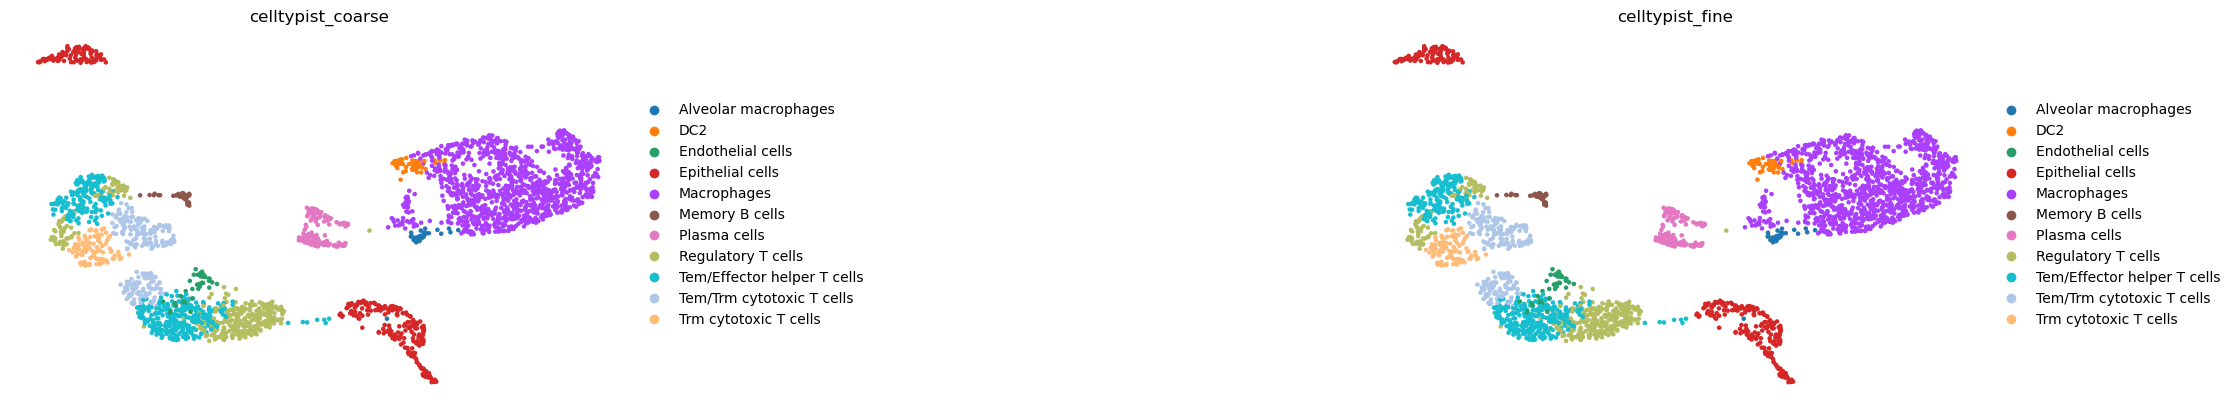

In [9]:
pred_high = celltypist.annotate(adata_ct, model=model_high, majority_voting=True)
pred_low  = celltypist.annotate(adata_ct, model=model_low,  majority_voting=True)

pred_high_adata = pred_high.to_adata()
pred_low_adata  = pred_low.to_adata()

adata.obs["celltypist_coarse"] = pred_high_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["celltypist_fine"]   = pred_low_adata.obs.loc[adata.obs.index,  "majority_voting"]

sc.pl.umap(adata, color=["celltypist_coarse","celltypist_fine"],
           frameon=False, wspace=1)

## ScType (liver-specific database)

In [ ]:
%%R
library(stats)  
library(Seurat)
library(dplyr)
library(HGNChelper)
library(openxlsx)
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")
gs_list <- gene_sets_prepare("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx", "Liver")

Loading required package: SeuratObject
Loading required package: sp

Attaching package: 'SeuratObject'

The following objects are masked from 'package:base':

    intersect, t


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.
In addition: Warning messages:
1: 
   File C:\Users\shoko\OneDrive\Documents/.Renviron contains invalid line(s)
tools40"
   They were ignored
 
2: In checkGeneSymbols(markers_all) :
  Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.
3: In checkGeneSymbols(markers_all) : x co

In [13]:
adata_seurat = adata.copy()
del adata_seurat.uns

with localconverter(default_converter + anndata2ri.converter):
    r_adata = ro.conversion.py2rpy(adata_seurat)
ro.globalenv["adata_seurat"] = r_adata

In [15]:
%%R
expr_matrix <- assay(adata_seurat, "logcounts")
es_max <- sctype_score(scRNAseqData=expr_matrix, scaled=TRUE,
                       gs=gs_list$gs_positive, gs2=gs_list$gs_negative)
clusters <- colData(adata_seurat)$leiden_res_0.50
cl_results <- lapply(unique(clusters), function(cl) {
    cells <- which(clusters == cl)
    es    <- sort(rowSums(es_max[, cells, drop=FALSE]), decreasing=TRUE)
    data.frame(cluster=cl, cell_type=names(es)[1], score=es[1])
}) |> dplyr::bind_rows()
print(cl_results)
cluster_to_type <- setNames(cl_results$cell_type, cl_results$cluster)
colData(adata_seurat)$sctype_cell_type <- cluster_to_type[as.character(clusters)]

                         cluster              cell_type      score
Kupffer cells...1              0          Kupffer cells 1068.09619
Hepatocytes...2                1            Hepatocytes  870.94599
Immune system cells...3        2    Immune system cells 1101.11147
Kupffer cells...4              3          Kupffer cells  981.09913
Kupffer cells...5              4          Kupffer cells  863.70445
Hepatocytes...6                5            Hepatocytes   85.61424
Kupffer cells...7              6          Kupffer cells 1267.42108
Kupffer cells...8              7          Kupffer cells  213.93541
Immune system cells...9        8    Immune system cells  147.08436
Hepatocytes...10               9            Hepatocytes  289.45241
Hepatic stellate cells        10 Hepatic stellate cells  111.35504
Immune system cells...12      11    Immune system cells  346.57091
Immune system cells...13      12    Immune system cells  477.50144
Cholangiocytes                13         Cholangiocytes  384.4

In addition: Warning message:
In sctype_score(scRNAseqData = expr_matrix, scaled = TRUE, gs = gs_list$gs_positive,  :
  scRNAseqData doesn't seem to be a matrix


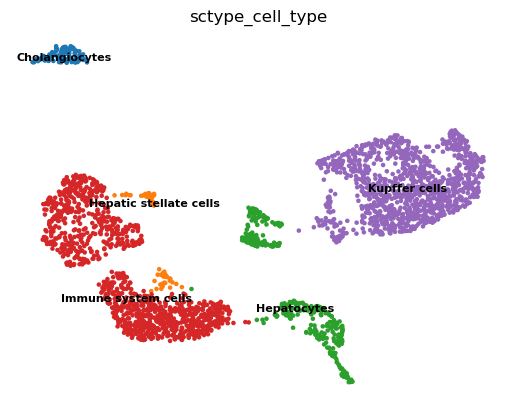

In [16]:
with localconverter(default_converter + pandas2ri.converter):
    col_data = ro.conversion.rpy2py(ro.r("as.data.frame(colData(adata_seurat))"))
adata.obs["sctype_cell_type"] = col_data["sctype_cell_type"].values
adata.obs["sctype_cell_type"] = adata.obs["sctype_cell_type"].astype("category")
sc.pl.umap(adata, color="sctype_cell_type", legend_loc="on data",
           legend_fontsize=8, frameon=False)

## SingleR

In [17]:
%%R
library(SingleR); library(celldex)
ref_hpca  <- HumanPrimaryCellAtlasData()
pred_hpca <- SingleR(test=adata_seurat, ref=ref_hpca,
                     labels=ref_hpca$label.main)
colData(adata_seurat)$SingleR_HPCA <- pred_hpca$pruned.labels


Attaching package: 'celldex'

The following objects are masked from 'package:SingleR':

    BlueprintEncodeData, DatabaseImmuneCellExpressionData,
    HumanPrimaryCellAtlasData, ImmGenData, MonacoImmuneData,
    MouseRNAseqData, NovershternHematopoieticData



In [18]:
with localconverter(default_converter + pandas2ri.converter):
    labels = ro.conversion.rpy2py(ro.r("as.data.frame(colData(adata_seurat))"))
adata.obs["SingleR_HPCA"] = labels["SingleR_HPCA"].values

## Manual marker scoring & 4-way majority vote

In [19]:
MARKER_SETS = {
    "Macrophage" : ["CD68","MARCO","CSF1R","MRC1","VSIG4","GPNMB","SPP1","C1QA","C1QB","TIMD4"],
    "Monocyte"   : ["CD14","LYZ","S100A8","S100A9","FCN1","VCAN","CXCL8"],
    "T_cell"     : ["CD3D","CD3E","TRAC","TRBC2","IL7R","CD2"],
    "CD8_T_cell" : ["CD8A","CD8B","GZMK","GZMA","GZMB","PRF1","CCL5"],
    "NK_ILC"     : ["NKG7","GNLY","NCAM1","KLRB1","KLRD1","TYROBP"],
    "B_cell"     : ["MS4A1","CD79A","CD79B","IGHM","IGHD"],
    "Plasma_cell": ["MZB1","JCHAIN","IGHG1","XBP1","SDC1","PRDM1"],
    "DC"         : ["FCER1A","CLEC10A","CST3","CLEC9A","CD1C"],
    "Hepatocyte" : ["ALB","APOC3","TTR","FGB","FGG","CYP3A4","GPC3","APOE","FABP1"],
    "Fibroblast" : ["COL1A1","COL1A2","COL3A1","DCN","LUM","ACTA2","PDGFRB","FAP"],
    "Endothelial": ["PECAM1","VWF","CDH5","CLDN5","LYVE1","ENG"],
}

import seaborn as sns
score_rows = []
for cl in sorted(adata.obs["leiden_res_0.50"].unique(), key=int):
    mask = adata.obs["leiden_res_0.50"] == cl
    row = {"cluster": cl}
    for ct, markers in MARKER_SETS.items():
        present = [g for g in markers if g in adata.var_names]
        if present:
            expr = adata[mask, present].X
            if hasattr(expr, "toarray"): expr = expr.toarray()
            row[ct] = float(expr.mean())
        else:
            row[ct] = 0.0
    score_rows.append(row)

score_df = pd.DataFrame(score_rows).set_index("cluster")
score_df["best_by_score"] = score_df.idxmax(axis=1)
print(score_df["best_by_score"])

cluster
0      Macrophage
1      Hepatocyte
2          T_cell
3      Macrophage
4        Monocyte
5     Plasma_cell
6      Macrophage
7      Macrophage
8      CD8_T_cell
9      Hepatocyte
10         B_cell
11         T_cell
12         T_cell
13       Monocyte
Name: best_by_score, dtype: object


In [20]:
from collections import Counter

def majority(series):
    return series.value_counts().index[0]

vote_df = pd.DataFrame({
    "n_cells"      : adata.obs.groupby("leiden_res_0.50").size(),
    "CellTypist"   : adata.obs.groupby("leiden_res_0.50")["celltypist_fine"].apply(majority),
    "ScType"       : adata.obs.groupby("leiden_res_0.50")["sctype_cell_type"].apply(majority),
    "SingleR_HPCA" : adata.obs.groupby("leiden_res_0.50")["SingleR_HPCA"].apply(majority),
})

# ScType gets double weight for parenchymal (liver-specific DB)
def assign_label(row):
    parenchymal = {"Hepatocyte","Fibroblast","Endothelial"}
    votes = [row["CellTypist"], row["ScType"], row["SingleR_HPCA"],
             score_df.loc[row.name, "best_by_score"]]
    if row["ScType"] in parenchymal:
        votes.append(row["ScType"])
    winner, _ = Counter(votes).most_common(1)[0]
    return winner

vote_df["final_label"] = vote_df.apply(assign_label, axis=1)
print(vote_df[["n_cells","final_label"]].to_string())

                 n_cells                  final_label
leiden_res_0.50                                      
0                    297                   Macrophage
1                    173                  Hepatocytes
2                    585  Tem/Effector helper T cells
3                    289                   Macrophage
4                    248                     Monocyte
5                    124                 Plasma cells
6                    247                   Macrophage
7                     77                   Macrophage
8                     78    Tem/Trm cytotoxic T cells
9                     34                  Hepatocytes
10                    61                       B_cell
11                   220  Tem/Effector helper T cells
12                   264    Tem/Trm cytotoxic T cells
13                    98             Epithelial cells


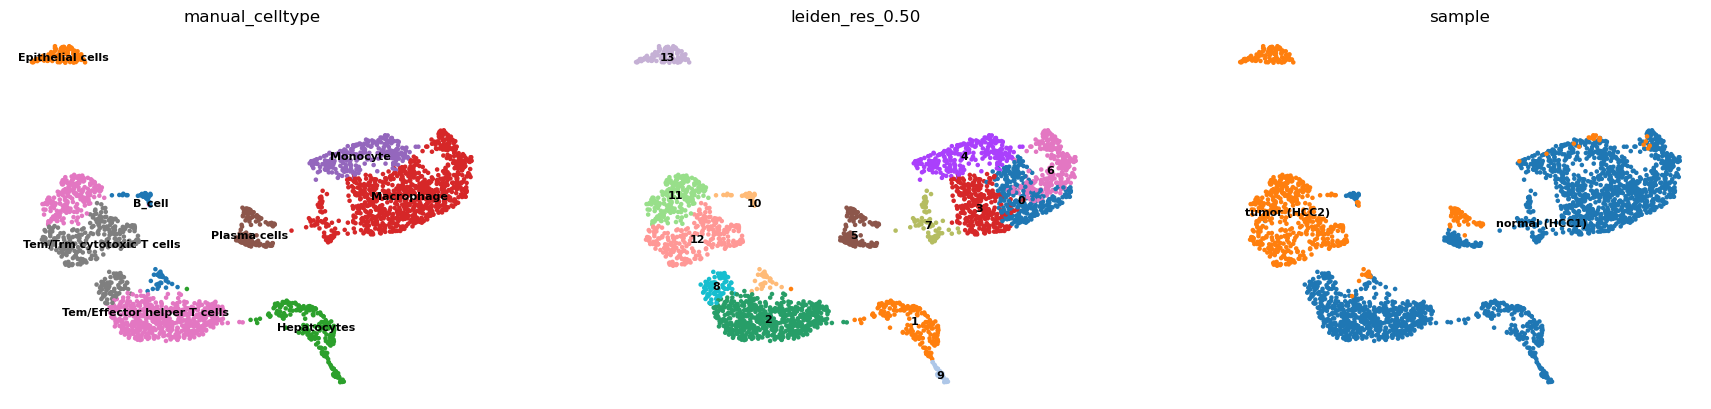

In [21]:
cluster_to_celltype = vote_df["final_label"].to_dict()
adata.obs["manual_celltype"] = (
    adata.obs["leiden_res_0.50"].astype(str).map(cluster_to_celltype).astype("category"))

sc.pl.umap(adata, color=["manual_celltype","leiden_res_0.50","sample"],
           legend_loc="on data", legend_fontsize=8, frameon=False, ncols=3)

In [22]:
# Ensure all columns in adata.obs are of supported types
for col in adata.obs.columns:
    if adata.obs[col].dtype == "object":
        adata.obs[col] = adata.obs[col].astype(str)
    elif adata.obs[col].dtype.name == "category":
        adata.obs[col] = adata.obs[col].astype(str).astype("category")

# Save the AnnData object
adata.write("../data/processed/adata_annotated.h5ad")
print("Saved: adata_annotated.h5ad")

... storing 'SingleR_HPCA' as categorical


Saved: adata_annotated.h5ad
